Scan free parameters in the Saarelma et al., 2023 model. These parameters are:
    alpha_crit : float
        FREE PARAMETER, Critical alpha value for onset of infinite-n ballooning instability, dimensionless
    C_KBM : float
        FREE PARAMETER, KBM diffusion coefficient, m^2/s
    De_chie_etg : float
        FREE PARAMETER, ETG diffusion coefficient, m^2/s
    nFC_x0 : float
        m^-3, FREE PARAMETER, Franck-Condon neutral density at the separatrix (boundary condition)

In [1]:
import sys
from pathlib import Path
import csv


# Put repo root on path so `src` is importable (parent of this notebook's folder).
ROOT = Path.cwd()
ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.solver import saarelma_connor
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Input files
mhd_fp = '/Users/nelsonlab/codes/saarelma-conner-ped/src/inputs/g192185.02440' # filepath to MHD paramter file
kprof_fp = '/Users/nelsonlab/codes/saarelma-conner-ped/src/inputs/p193754.1850.0' # filepath to kinetic paramter file

# Scan parameters
alpha_crits = np.linspace(0.01, 2.0, 5)
C_KBMs = np.linspace(0.01, 0.9, 5)
De_chie_etgs = np.linspace(0.01, 0.9, 5)
nFC_x0s = np.linspace(5e14, 9e15, 5)

# Static parameters
P_tot_e = 5e6 # W, total heating power given to electrons (can be assumed to be half the total heating power according to S. Saarelma et al 2023 Nucl. Fusion 63 052002), will be read from TokTox
solve_res = 100

# Output data and files
success_fp = 'success.txt'
failure_fp = 'failure.txt'
error_messages_fp = 'error_messages.txt'
with open(success_fp, 'w') as f:
        f.write(f"alpha_crit, C_KBM, De_chie_etg, nFC_x0\n")
with open(failure_fp, 'w') as f:
        f.write(f"alpha_crit, C_KBM, De_chie_etg, nFC_x0\n")
with open(error_messages_fp, 'w') as f:
        f.write(f"alpha_crit, C_KBM, De_chie_etg, nFC_x0, message\n")
ne_success_fp = 'scan_success'
verbose = False

In [ ]:
# run scan
i=0
j=0
k=0
l=0
for alpha_crit in alpha_crits:
        for C_KBM in C_KBMs:
                for De_chie_etg in De_chie_etgs:
                        for nFC_x0 in nFC_x0s:
                                alpha_crit = round(alpha_crit, 3)
                                C_KBM = round(C_KBM, 3)
                                De_chie_etg = round(De_chie_etg, 3)
                                nFC_x0 = round(nFC_x0, 3)
                                try:
                                        test_model = saarelma_connor(
                                                P_tot_e = P_tot_e,
                                                alpha_crit = alpha_crit,
                                                C_KBM = C_KBM,
                                                De_chie_etg = De_chie_etg,
                                                nFC_x0 = nFC_x0, # m^(-3)
                                                mhd_fp = mhd_fp,
                                                kprof_fp = kprof_fp,
                                                verbose = verbose
                                        )
                                        test_model.solve(x_res=solve_res)
                                except Exception as e: # run fails
                                        # write raw parameter combination to failure text file
                                        with open('failure.txt', 'a') as f:
                                                f.write(f"{alpha_crit}, {C_KBM}, {De_chie_etg}, {nFC_x0}\n")
                                        with open(error_messages_fp, 'a') as f:
                                                f.write(f"{alpha_crit}, {C_KBM}, {De_chie_etg}, {nFC_x0}, {e}\n")
                                else: # run works
                                        # write raw parameter combination to success text file
                                        with open('success.txt', 'a') as f:
                                                f.write(f"{alpha_crit}, {C_KBM}, {De_chie_etg}, {nFC_x0}\n")
                                        # write ne_success to ne_success file
                                        np.save(f'scan_success/ne_a{alpha_crit}_C{C_KBM}_D{De_chie_etg}_n{nFC_x0}',test_model.sol,allow_pickle=True)
                                l+=1
                        k+=1
                j+=1
                print(f"Completed {j} of {len(C_KBMs)} C_KBMs") # progress logging
        i+=1
        print(f"Completed {i} of {len(alpha_crits)} alpha_crits") # progress logging

/Users/nelsonlab/anaconda3/envs/sc_ped/lib/python3.14/site-packages/scipy/integrate/_bvp.py:476: RuntimeWarning: overflow encountered in dot
  cost_new = np.dot(step_new, step_new)
/Users/nelsonlab/codes/saarelma-conner-ped/src/solver.py:780: RuntimeWarning: overflow encountered in multiply
  d2Ndxi2 = A * N * dNdxi - B * N - K * dNdxi
/Users/nelsonlab/anaconda3/envs/sc_ped/lib/python3.14/site-packages/scipy/integrate/_bvp.py:41: RuntimeWarning: invalid value encountered in subtract
  df_dy[:, i, :] = (f_new - f0) / hi
/Users/nelsonlab/anaconda3/envs/sc_ped/lib/python3.14/site-packages/scipy/integrate/_bvp.py:568: RuntimeWarning: invalid value encountered in divide
  r_middle /= 1 + np.abs(f_middle)
/Users/nelsonlab/anaconda3/envs/sc_ped/lib/python3.14/site-packages/scipy/integrate/_bvp.py:569: RuntimeWarning: invalid value encountered in divide
  r1 /= 1 + np.abs(f1)
/Users/nelsonlab/anaconda3/envs/sc_ped/lib/python3.14/site-packages/scipy/integrate/_bvp.py:570: RuntimeWarning: invali

Completed 0.01 of 5 C_KBMs


/Users/nelsonlab/anaconda3/envs/sc_ped/lib/python3.14/site-packages/scipy/integrate/_bvp.py:310: RuntimeWarning: invalid value encountered in subtract
  0.125 * h * (f[:, 1:] - f[:, :-1]))
/Users/nelsonlab/codes/saarelma-conner-ped/src/solver.py:780: RuntimeWarning: invalid value encountered in subtract
  d2Ndxi2 = A * N * dNdxi - B * N - K * dNdxi
/Users/nelsonlab/anaconda3/envs/sc_ped/lib/python3.14/site-packages/scipy/integrate/_bvp.py:312: RuntimeWarning: invalid value encountered in add
  col_res = y[:, 1:] - y[:, :-1] - h / 6 * (f[:, :-1] + f[:, 1:] +
/Users/nelsonlab/anaconda3/envs/sc_ped/lib/python3.14/site-packages/scipy/integrate/_bvp.py:313: RuntimeWarning: overflow encountered in multiply
  4 * f_middle)
/Users/nelsonlab/anaconda3/envs/sc_ped/lib/python3.14/site-packages/scipy/integrate/_bvp.py:594: RuntimeWarning: invalid value encountered in add
  t = (yp[:, :-1] + yp[:, 1:] - 2 * slope) / h
/Users/nelsonlab/anaconda3/envs/sc_ped/lib/python3.14/site-packages/scipy/integra

Completed 0.232 of 5 C_KBMs
Completed 0.455 of 5 C_KBMs
Completed 0.678 of 5 C_KBMs
Completed 0.9 of 5 C_KBMs
Completed 0.01 of 5 alpha_crits


/Users/nelsonlab/anaconda3/envs/sc_ped/lib/python3.14/site-packages/scipy/integrate/_bvp.py:312: RuntimeWarning: overflow encountered in add
  col_res = y[:, 1:] - y[:, :-1] - h / 6 * (f[:, :-1] + f[:, 1:] +
/Users/nelsonlab/anaconda3/envs/sc_ped/lib/python3.14/site-packages/scipy/integrate/_bvp.py:38: RuntimeWarning: invalid value encountered in add
  y_new[i] += h[i]
/Users/nelsonlab/anaconda3/envs/sc_ped/lib/python3.14/site-packages/scipy/integrate/_bvp.py:39: RuntimeWarning: invalid value encountered in subtract
  hi = y_new[i] - y[i]
/Users/nelsonlab/anaconda3/envs/sc_ped/lib/python3.14/site-packages/scipy/integrate/_bvp.py:596: RuntimeWarning: invalid value encountered in subtract
  c[1] = (slope - yp[:, :-1]) / h - t
/Users/nelsonlab/anaconda3/envs/sc_ped/lib/python3.14/site-packages/scipy/integrate/_bvp.py:565: RuntimeWarning: invalid value encountered in subtract
  r1 = y1_prime - f1
/Users/nelsonlab/anaconda3/envs/sc_ped/lib/python3.14/site-packages/scipy/integrate/_bvp.py:56

Completed 0.01 of 5 C_KBMs
Completed 0.232 of 5 C_KBMs
Completed 0.455 of 5 C_KBMs
Completed 0.678 of 5 C_KBMs
Completed 0.9 of 5 C_KBMs
Completed 0.507 of 5 alpha_crits
Completed 0.01 of 5 C_KBMs
Completed 0.232 of 5 C_KBMs
Completed 0.455 of 5 C_KBMs
Completed 0.678 of 5 C_KBMs
Completed 0.9 of 5 C_KBMs
Completed 1.005 of 5 alpha_crits
Completed 0.01 of 5 C_KBMs
Completed 0.232 of 5 C_KBMs
Completed 0.455 of 5 C_KBMs
Completed 0.678 of 5 C_KBMs
Completed 0.9 of 5 C_KBMs
Completed 1.502 of 5 alpha_crits
Completed 0.01 of 5 C_KBMs
Completed 0.232 of 5 C_KBMs
Completed 0.455 of 5 C_KBMs
Completed 0.678 of 5 C_KBMs
Completed 0.9 of 5 C_KBMs
Completed 2.0 of 5 alpha_crits


PLOTTING AND ANALYSIS

In [8]:
# success/failure heat maps of each slice of two of the variables of choice

# variables to slice on
slice_var1_name = 'alpha_crit'
slice_var2_name = 'De_chie_etg'

# value of variables to slice on
slice_var1 = 0.01
slice_var2 = 0.9

success_fn = 'success.txt'
# ne_success = []
names = ['alpha_crit', 'C_KBM', 'De_chie_etg', 'nFC_x0']

idx_var = [names.index(slice_var1_name), names.index(slice_var2_name)]
idx_notvar = [i for i in range(len(names)) if i not in idx_var]

var1 = []
var2 = []
with open(success_fn, newline="") as f:
    reader = csv.reader(f)
    header = next(reader)  # skip: alpha_crit, C_KBM, ...
    for row in reader:
        numbers = [float(x.strip()) for x in row]
        # alpha_crit, C_KBM, De_chie_etg, nFC_x0 = numbers
        if numbers[idx_var[0]] == slice_var1 or numbers[idx_var[1]] == slice_var1: # sliced row
            if numbers[idx_var[0]] == slice_var2 or numbers[idx_var[1]] == slice_var2: # sliced row
                var1.append(numbers[idx_notvar[0]])
                var2.append(numbers[idx_notvar[1]])



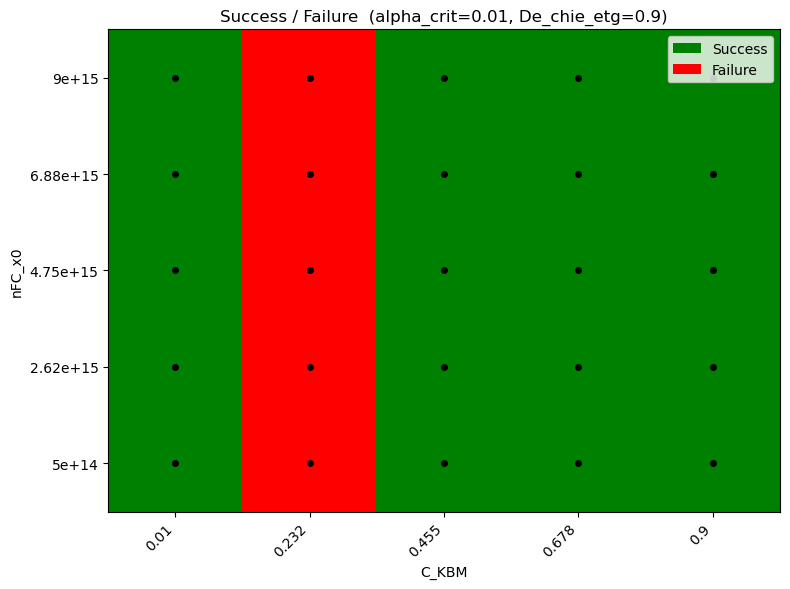

In [10]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# Map each parameter name to its scan array
scan_arrays = {
    'alpha_crit':  alpha_crits,
    'C_KBM':       C_KBMs,
    'De_chie_etg': De_chie_etgs,
    'nFC_x0':      nFC_x0s,
}

# Derive axis labels and tick values automatically from idx_notvar and names
x_name = names[idx_notvar[0]]
y_name = names[idx_notvar[1]]
x_vals = sorted(set(round(v, 3) for v in scan_arrays[x_name]))
y_vals = sorted(set(round(v, 3) for v in scan_arrays[y_name]))

title = (f"Success / Failure  "
         f"({slice_var1_name}={slice_var1}, {slice_var2_name}={slice_var2})")

# Set of successful (x, y) pairs collected above
success_pairs = set(zip(var1, var2))

# Build binary grid: 1 = success (green), 0 = failure (red)
grid = np.zeros((len(y_vals), len(x_vals)))
for xi, x in enumerate(x_vals):
    for yi, y in enumerate(y_vals):
        if (x, y) in success_pairs:
            grid[yi, xi] = 1

fig, ax = plt.subplots(figsize=(8, 6))
cmap = ListedColormap(["red", "green"])
ax.imshow(grid, cmap=cmap, vmin=0, vmax=1, aspect="auto", origin="lower")

# dot at every grid point
for xi in range(len(x_vals)):
    for yi in range(len(y_vals)):
        ax.plot(xi, yi, "k.", markersize=8)

ax.set_xticks(range(len(x_vals)))
ax.set_xticklabels([f"{v:.3g}" for v in x_vals], rotation=45, ha="right")
ax.set_yticks(range(len(y_vals)))
ax.set_yticklabels([f"{v:.3g}" for v in y_vals])
ax.set_xlabel(x_name)
ax.set_ylabel(y_name)
ax.set_title(title)

ax.legend(
    handles=[Patch(facecolor="green", label="Success"),
             Patch(facecolor="red",   label="Failure")],
    loc="upper right",
)

plt.tight_layout()
plt.show()